# CS 6476 Project 1: Image Filtering and Hybrid Images

All projects in this course will be done with these iPython notebooks. These are convenient ways for you to quickly and easily interact with the code. A notebook contains many blocks of code, each of which can be run independently. You can run a cell with ctrl+enter or shift+enter (to move to the next cell).

If there are any notes you wish to leave for the TAs as they test your code, you may leave them here.

## Setup

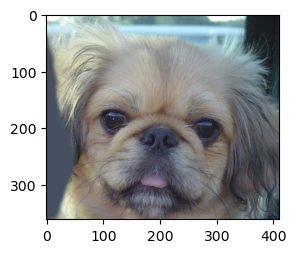

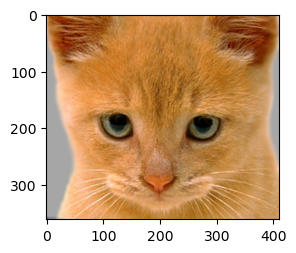

In [1]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from utils import vis_hybrid_image, load_image, save_image, im_range
from student_code import my_imfilter, create_hybrid_image
%load_ext autoreload
%autoreload 2

image1 = load_image('../data/dog.bmp')
image2 = load_image('../data/cat.bmp')

# display the dog and cat images
plt.figure(figsize=(3,3)); plt.imshow((image1*255).astype(np.uint8));
plt.figure(figsize=(3,3)); plt.imshow((image2*255).astype(np.uint8));

## Create filter

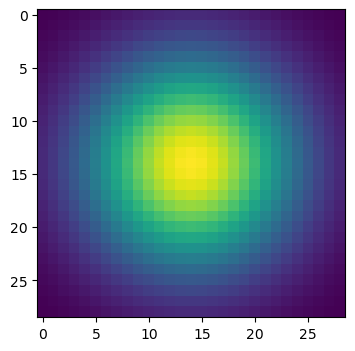

In [2]:
cutoff_frequency = 7
filter = cv2.getGaussianKernel(ksize=cutoff_frequency*4+1,
                               sigma=cutoff_frequency)
filter = np.dot(filter, filter.T)

# let's take a look at the filter!
plt.figure(figsize=(4,4)); plt.imshow(filter);

## Apply filter to image
Both functions you need to implement in this project can be found in _student_\__code.py_. Start by implementing _my_\__imfilter_, which takes both a filter and an image, and returns the filtered image. This code block will use your _my_\__imfilter_ function to create and display a blurry version of the dog image.

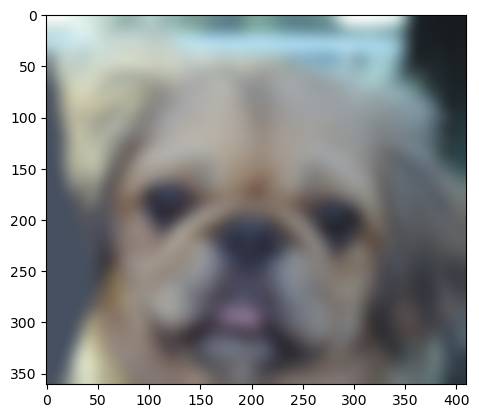

In [3]:
blurry_dog = my_imfilter(image1, filter)
plt.figure(); plt.imshow((blurry_dog*255).astype(np.uint8));

## Create hybrid image
Next, implement _create_\__hybrid_\__image_, which takes two images and makes a hybrid image using the low frequency content from one image and the high frequency content from another.

In [4]:
low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter)
vis = vis_hybrid_image(hybrid_image)

## Show results

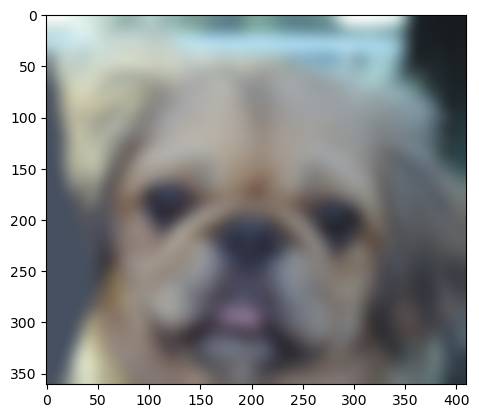

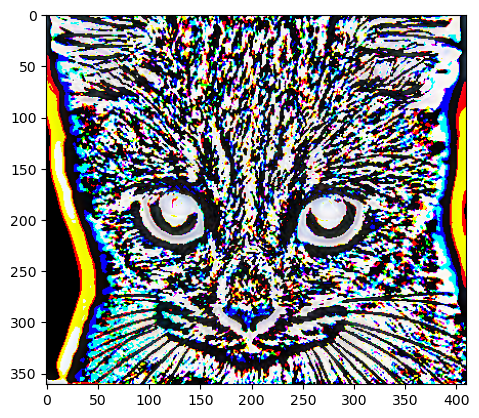

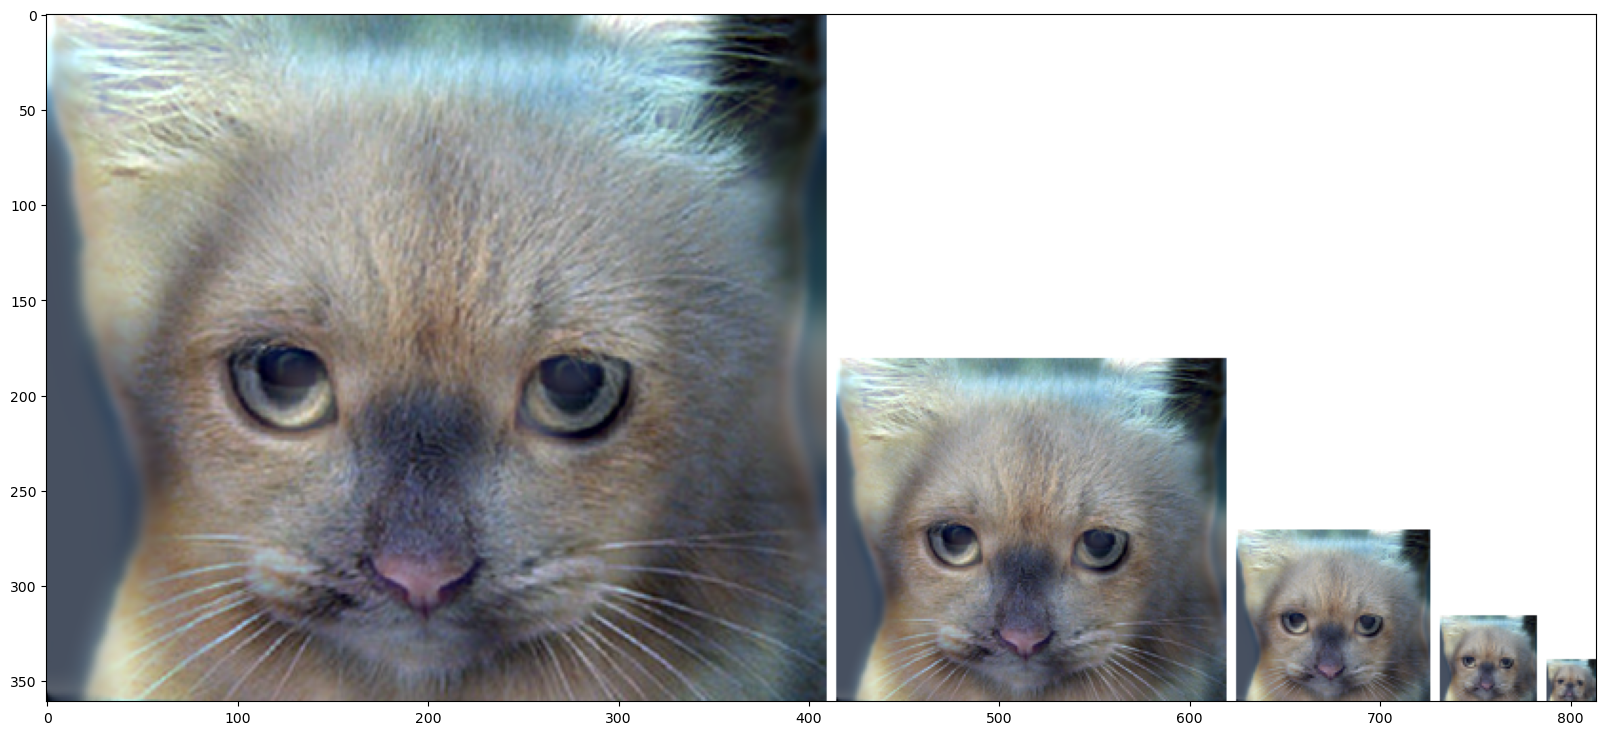

In [5]:
# 检查高频、低频图像是否正确，若不正确请检查是否已调整图像强度值到[0,1]范围内
plt.figure(); plt.imshow((low_frequencies*255).astype(np.uint8));
plt.figure(); plt.imshow((high_frequencies*255).astype(np.uint8));
plt.figure(figsize=(20, 20)); plt.imshow(vis);

## Save results

In [6]:
save_image('../results/low_frequencies.jpg', low_frequencies)
save_image('../results/high_frequencies.jpg', high_frequencies)
save_image('../results/hybrid_image.jpg', hybrid_image)
save_image('../results/hybrid_image_scales.jpg', vis)

True

Generated writeup examples:
('bird_plane', 7)
('submarine_fish', 7)
('einstein_marilyn', 7)
('motorcycle_bicycle', 7)
('arknights_honkai', 7)


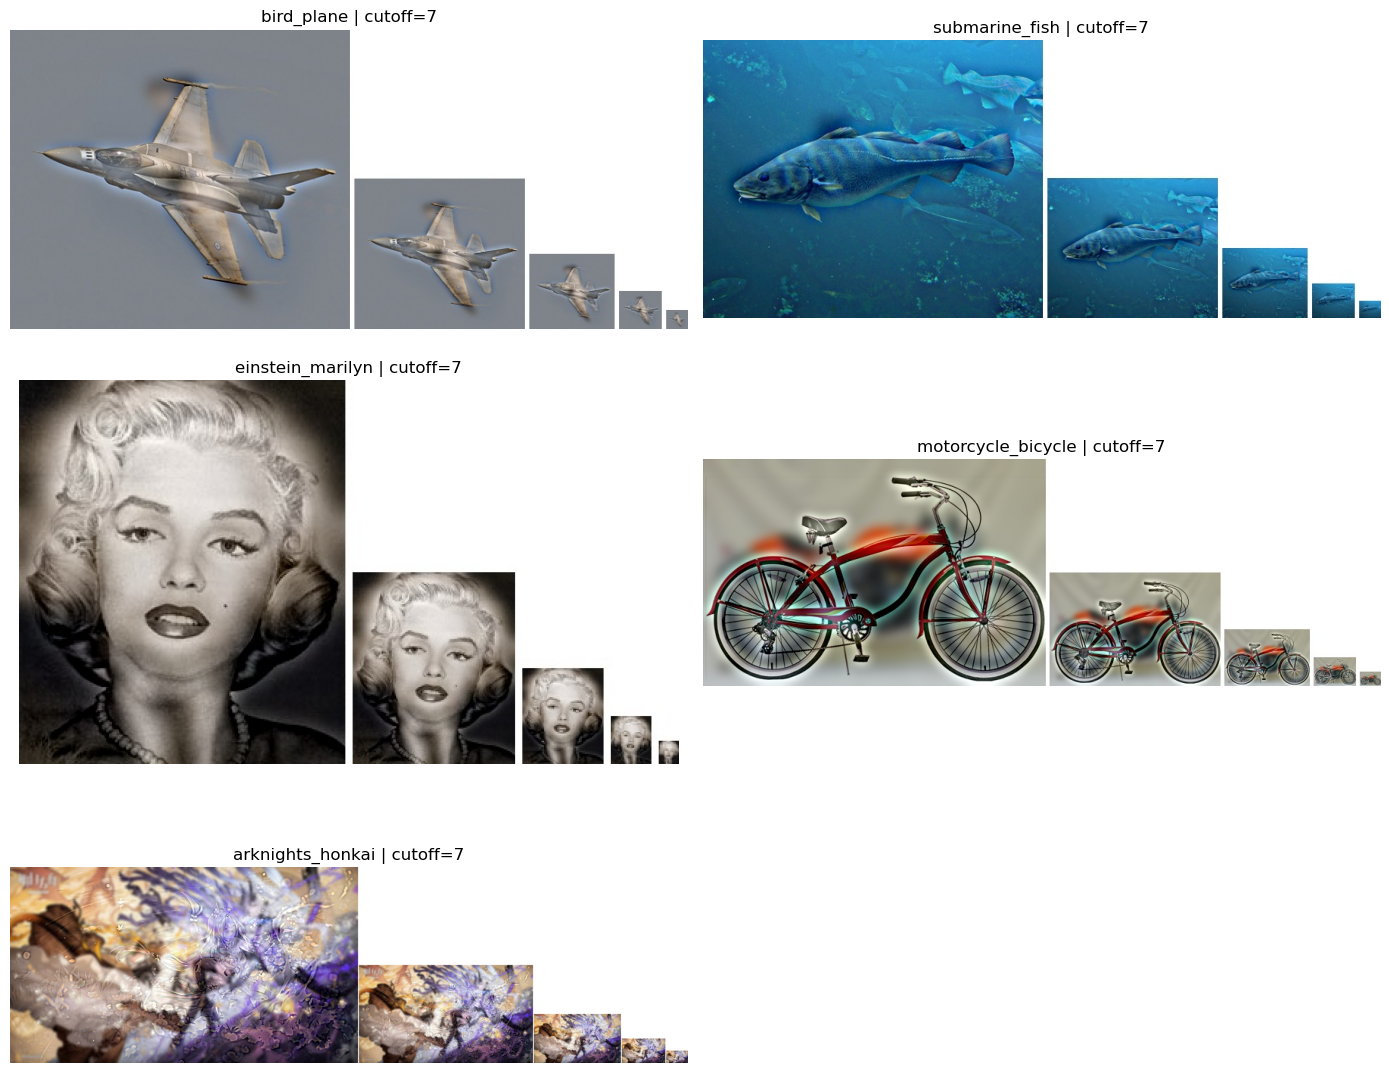

In [8]:
# Writeup module: generate several hybrid-image combinations (fixed cutoff, no parameter tuning)
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import load_image, save_image, vis_hybrid_image
from student_code import create_hybrid_image

WRITEUP_IMAGE_PATHS = {
    'bird': '../data/bird.bmp',
    'plane': '../data/plane.bmp',
    'submarine': '../data/submarine.bmp',
    'fish': '../data/fish.bmp',
    'einstein': '../data/einstein.bmp',
    'marilyn': '../data/marilyn.bmp',
    'motorcycle': '../data/motorcycle.bmp',
    'bicycle': '../data/bicycle.bmp',
    'arknights': '../data/arknights.png',
    'honkai': '../data/Honkai_Starrail.jpg',
}

# At least 5 combinations for writeup
WRITEUP_PAIRS = [
    ('bird', 'plane'),
    ('submarine', 'fish'),
    ('einstein', 'marilyn'),
    ('motorcycle', 'bicycle'),
    ('arknights', 'honkai'),
]

WRITEUP_CUTOFF = 7
writeup_dir = '../results/writeup_hybrid_examples'
os.makedirs(writeup_dir, exist_ok=True)

def _gaussian_filter(cutoff):
    g = cv2.getGaussianKernel(ksize=cutoff * 4 + 1, sigma=cutoff)
    return np.dot(g, g.T)

def _resize_to_match(reference_img, img_to_resize):
    h, w = reference_img.shape[:2]
    return cv2.resize(img_to_resize, (w, h), interpolation=cv2.INTER_LINEAR)

kernel = _gaussian_filter(WRITEUP_CUTOFF)
generated = []

for name1, name2 in WRITEUP_PAIRS:
    image1 = load_image(WRITEUP_IMAGE_PATHS[name1])
    image2 = load_image(WRITEUP_IMAGE_PATHS[name2])

    # Keep pipeline robust when source sizes differ.
    if image1.shape != image2.shape:
        image2 = _resize_to_match(image1, image2)

    low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)
    vis = vis_hybrid_image(hybrid_image)

    pair_name = f'{name1}_{name2}'
    pair_dir = os.path.join(writeup_dir, pair_name)
    os.makedirs(pair_dir, exist_ok=True)

    save_image(os.path.join(pair_dir, 'low.jpg'), low_frequencies)
    save_image(os.path.join(pair_dir, 'high.jpg'), high_frequencies)
    save_image(os.path.join(pair_dir, 'hybrid.jpg'), hybrid_image)
    save_image(os.path.join(pair_dir, 'hybrid_scales.jpg'), vis)

    generated.append((pair_name, WRITEUP_CUTOFF))

print('Generated writeup examples:')
for item in generated:
    print(item)

# Quick preview of the hybrid_scales images
cols = 2
rows = int(np.ceil(len(WRITEUP_PAIRS) / cols))
plt.figure(figsize=(14, 4 * rows))

for i, (name1, name2) in enumerate(WRITEUP_PAIRS, 1):
    pair_name = f'{name1}_{name2}'
    vis_path = os.path.join(writeup_dir, pair_name, 'hybrid_scales.jpg')
    if not os.path.exists(vis_path):
        continue
    vis_img = load_image(vis_path)
    plt.subplot(rows, cols, i)
    plt.imshow((vis_img * 255).astype(np.uint8))
    plt.title(f'{pair_name} | cutoff={WRITEUP_CUTOFF}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Several Examples of Hybrid Images (5 Combinations) - Writeup

In this section, I present five hybrid-image examples generated with a fixed Gaussian cutoff frequency (`cutoff = 7`) using my implemented `create_hybrid_image` pipeline. For each pair, the high-frequency content is taken from the second image and mixed with the low-frequency content from the first image. The `hybrid_scales` visualization is used to verify near-view and far-view perception.

### 1) bird + plane
**Image pair:** `bird.bmp` and `plane.bmp`  
**Observation:** At larger scales, aircraft contours are more noticeable, while at smaller scales the overall object silhouette remains coherent. The fusion is stable but somewhat edge-dominant, indicating strong high-frequency contribution from the plane texture.

![bird_plane](../results/writeup_hybrid_examples/bird_plane/hybrid_scales.jpg)

### 2) submarine + fish
**Image pair:** `submarine.bmp` and `fish.bmp`  
**Observation:** This pair gives a smooth transition across scales. The fish body details are clear in close view, while low-frequency underwater structure remains visible from a distance. This is one of the most natural blends among the tested pairs.

![submarine_fish](../results/writeup_hybrid_examples/submarine_fish/hybrid_scales.jpg)

### 3) einstein + marilyn
**Image pair:** `einstein.bmp` and `marilyn.bmp`  
**Observation:** Facial hybrid images are highly effective. Fine facial features dominate at close range, while global facial shape and lighting dominate when viewed smaller/farther. The scale transition is clear and consistent with the expected hybrid-image effect.

![einstein_marilyn](../results/writeup_hybrid_examples/einstein_marilyn/hybrid_scales.jpg)

### 4) motorcycle + bicycle
**Image pair:** `motorcycle.bmp` and `bicycle.bmp`  
**Observation:** Wheel spokes and frame edges provide rich high-frequency signals. The result preserves a strong bicycle structure overall, while close inspection reveals additional sharp line details from the other vehicle. The mixed geometry creates a clear two-level perception.

![motorcycle_bicycle](../results/writeup_hybrid_examples/motorcycle_bicycle/hybrid_scales.jpg)

### 5) arknights (png) + honkai (jpg)
**Image pair:** `arknights.png` and `Honkai_Starrail.jpg`  
**Observation:** This cross-format pair (PNG/JPG) also forms a valid hybrid image. The blend is visually complex due to dense textures and color variation, but multi-scale viewing still shows distinguishable dominance changes across distances.

![arknights_honkai](../results/writeup_hybrid_examples/arknights_honkai/hybrid_scales.jpg)

### Summary
- I successfully generated **five distinct hybrid combinations** for writeup requirements.
- Hybrid perception is strongest for pairs with clear structural low-frequency content and clean high-frequency edges (e.g., face and underwater pairs).
- Highly textured/colorful pairs can still work, but may appear visually busy and require more careful interpretation across scales.

## Extra Credit: Parameter Tuning Study

bonus选择：调整cutoff参数并进行分析


注意事项：
1. 每对图像必须已经对齐且尺寸一致
2. 每对图像命名清晰，便于写报告
3. 路径统一放在 `../data/` 下，方便打包和复现

Extra credit results generated:
('dog_cat', 1, '../results/extra_credit\\dog_cat\\cutoff_1_hybrid_scales.jpg')
('dog_cat', 2, '../results/extra_credit\\dog_cat\\cutoff_2_hybrid_scales.jpg')
('dog_cat', 3, '../results/extra_credit\\dog_cat\\cutoff_3_hybrid_scales.jpg')
('dog_cat', 4, '../results/extra_credit\\dog_cat\\cutoff_4_hybrid_scales.jpg')
('dog_cat', 5, '../results/extra_credit\\dog_cat\\cutoff_5_hybrid_scales.jpg')
('dog_cat', 6, '../results/extra_credit\\dog_cat\\cutoff_6_hybrid_scales.jpg')
('dog_cat', 7, '../results/extra_credit\\dog_cat\\cutoff_7_hybrid_scales.jpg')
('dog_cat', 8, '../results/extra_credit\\dog_cat\\cutoff_8_hybrid_scales.jpg')
('submarine_fish', 1, '../results/extra_credit\\submarine_fish\\cutoff_1_hybrid_scales.jpg')
('submarine_fish', 2, '../results/extra_credit\\submarine_fish\\cutoff_2_hybrid_scales.jpg')
('submarine_fish', 3, '../results/extra_credit\\submarine_fish\\cutoff_3_hybrid_scales.jpg')
('submarine_fish', 4, '../results/extra_credit\\submarine

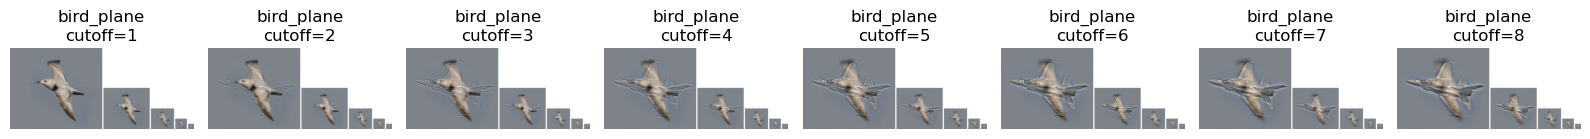

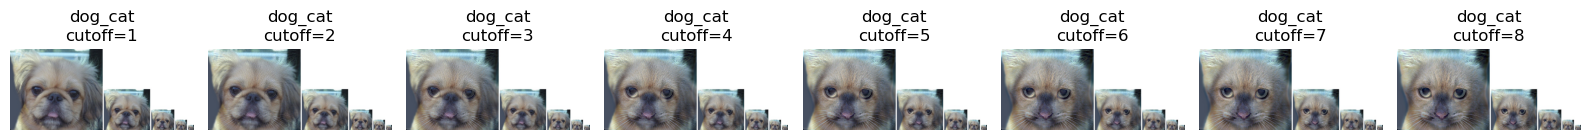

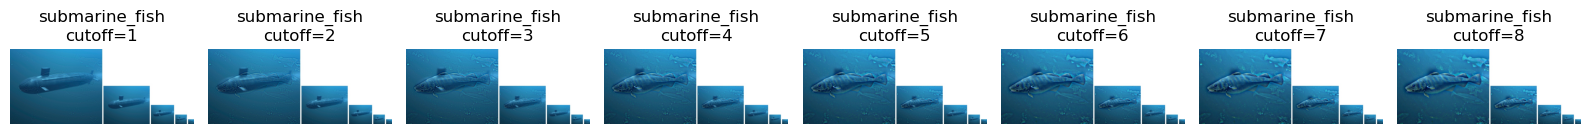

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import vis_hybrid_image, load_image, save_image
from student_code import create_hybrid_image

# ===== 在这里填写测试的图片对 =====
# 格式: (pair_name, image1_path, image2_path)
# 路径放在 ../data/ 下
EXTRA_PAIRS = [
    ('dog_cat', '../data/dog.bmp', '../data/cat.bmp'),
    ('submarine_fish', '../data/submarine.bmp', '../data/fish.bmp'),
    ('bird_plane', '../data/bird.bmp', '../data/plane.bmp'),
]


CUTOFF_LIST = [1, 2, 3, 4, 5, 6, 7, 8]

# 输出目录
extra_dir = '../results/extra_credit'
os.makedirs(extra_dir, exist_ok=True)

summary = []
skipped = []

for pair_name, img1_path, img2_path in EXTRA_PAIRS:
    if (not os.path.exists(img1_path)) or (not os.path.exists(img2_path)):
        skipped.append((pair_name, 'missing file'))
        continue

    image1 = load_image(img1_path)
    image2 = load_image(img2_path)

    if image1.shape != image2.shape:
        skipped.append((pair_name, f'shape mismatch: {image1.shape} vs {image2.shape}'))
        continue

    pair_dir = os.path.join(extra_dir, pair_name)
    os.makedirs(pair_dir, exist_ok=True)

    for cutoff_frequency in CUTOFF_LIST:
        g = cv2.getGaussianKernel(ksize=cutoff_frequency * 4 + 1, sigma=cutoff_frequency)
        filter = np.dot(g, g.T)

        low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter)
        vis = vis_hybrid_image(hybrid_image)

        prefix = os.path.join(pair_dir, f'cutoff_{cutoff_frequency}')
        save_image(prefix + '_low.jpg', low_frequencies)
        save_image(prefix + '_high.jpg', high_frequencies)
        save_image(prefix + '_hybrid.jpg', hybrid_image)
        save_image(prefix + '_hybrid_scales.jpg', vis)

        summary.append((pair_name, cutoff_frequency, prefix + '_hybrid_scales.jpg'))

print('Extra credit results generated:')
for item in summary:
    print(item)

if skipped:
    print('\nSkipped pairs:')
    for item in skipped:
        print(item)

# 额外可视化：展示每一对图像在不同 cutoff 下的 hybrid_scales
valid_pairs = sorted(set([p for p, _, _ in summary]))
for pair_name in valid_pairs:
    plt.figure(figsize=(16, 4))
    plot_idx = 1
    for cutoff_frequency in CUTOFF_LIST:
        path = os.path.join(extra_dir, pair_name, f'cutoff_{cutoff_frequency}_hybrid_scales.jpg')
        if not os.path.exists(path):
            continue
        vis_img = load_image(path)
        plt.subplot(1, len(CUTOFF_LIST), plot_idx)
        plt.imshow((vis_img * 255).astype(np.uint8))
        plt.title(f'{pair_name}\ncutoff={cutoff_frequency}')
        plt.axis('off')
        plot_idx += 1
    plt.tight_layout()
    plt.show()

# Extra credit 的 writeup

## Cutoff 参数影响分析（基于 `results/extra_credit`）

本部分只分析 `extra_credit` 文件夹中的结果图（`dog_cat`、`submarine_fish`、`bird_plane`），并比较不同 cutoff 对 hybrid image 的影响。

我测试的 cutoff 范围为 `1~8`。总体规律如下：
- cutoff 较小（如 1~2）：高频成分过强，边缘和纹理更锐利，但容易出现重影/轮廓冲突，远距离观察时整体形状不够稳定。
- cutoff 中等（如 3~6）：高频与低频平衡更好，近看细节明显，远看主体轮廓也更自然，通常是观感最稳定的区间。
- cutoff 较大（如 7~8）：高频被抑制得更多，图像更平滑，重影减少，但“近看另一张图”的效果会减弱，切换感变得不够强。

## 各组合观察

### 1) dog_cat
- `cutoff=1` 时，口鼻和毛发细节非常突出，但轮廓冲突明显，混合偏“锐”。
- `cutoff=4` 时，猫的整体五官与狗的高频细节达到较好平衡，切换感更自然。
- `cutoff=8` 时，结果更平滑、稳定，但高频特征减弱，近看冲击力下降。
- 结论：该组在中等 cutoff（约 4~6）表现最好。

### 2) submarine_fish
- `cutoff=1` 时，鱼和潜艇的边缘叠加感较强，局部有明显双轮廓。
- `cutoff=4` 时，鱼体纹理清晰且背景结构连贯，远近切换最自然。
- `cutoff=8` 与 `cutoff=4` 观感接近，但整体更柔和，细节对比略弱。
- 结论：该组在 4 左右已经达到较好平衡，继续增大 cutoff 收益有限。

### 3) bird_plane
- `cutoff=1` 时，鸟与飞机边缘冲突最明显，局部伪影较多。
- `cutoff=4` 时，飞机形状清晰、鸟的细节仍可感知，主观质量显著提升。
- `cutoff=8` 时，图像较稳定但高频“混合感”下降，整体更接近单一主体。
- 结论：该组同样更适合中等 cutoff（约 4~6）。

## 总结
- 从三组结果看，`cutoff` 主要控制“细节保留 vs 平滑稳定”的权衡。
- 太小会导致高频过强和重影，太大又会削弱 hybrid 的双重感知。
- 在本实验数据中，中等 cutoff（尤其约 `4~6`）整体表现最稳健。
- 因此，若无额外先验，建议先从中等 cutoff 开始，再按具体图像内容微调。

In [ ]:
import os
from utils import load_image


bird = load_image('../data/bird.bmp')
fish = load_image('../data/fish.bmp')
bicycle = load_image('../data/bicycle.bmp')
einstein = load_image('../data/einstein.bmp')
marilyn = load_image('../data/marilyn.bmp')
motorcycle = load_image('../data/motorcycle.bmp')
plane= load_image('../data/plane.bmp')
submarine = load_image('../data/submarine.bmp')
arknights= load_image('../data/arknights.png')
Honkai_Starrail= load_image('../data/Honkai_Starrail.jpg')
print('bird shape:', bird.shape)
print('fish shape:', fish.shape)
print('bicycle shape:', bicycle.shape)
print('einstein shape:', einstein.shape)
print('marilyn shape:', marilyn.shape)
print('motorcycle shape:', motorcycle.shape)
print('plane shape:', plane.shape)
print('submarine shape:', submarine.shape)
print('arknights shape:', arknights.shape)
print('Honkai_Starrail shape:', Honkai_Starrail.shape)

bird shape: (331, 375, 3)
fish shape: (307, 375, 3)
bicycle shape: (300, 453, 3)
einstein shape: (265, 225, 3)
marilyn shape: (265, 225, 3)
motorcycle shape: (300, 453, 3)
plane shape: (331, 375, 3)
submarine shape: (307, 375, 3)
arknights shape: (1080, 1920, 3)
Honkai_Starrail shape: (1080, 1920, 3)
